# Order of Accuracy of Finite Difference Formulas

## Pablo Requeijo

This notebook corresponds to the first session of the HPC class. It reads the results produced by the C++ program (`build/results.h5`) and checks that:


- The forward difference formula $\dfrac{f_{i+1}-f_i}{\Delta x} = f'(x)$ is **first-order accurate**: $\varepsilon \sim O(\Delta x)$
- The central difference formula $\dfrac{f_{i+1}-f_{i-1}}{2\Delta x} = f'(x)$ is **second-order accurate**: $\varepsilon \sim O(\Delta x^2)$

We will use $f(x) = \sin(x)$ as the test function, given that we know the exact derivative $f'(x) = \cos(x)$.

## Problem context

In numerical simulations, continuous quantities are represented on a **discrete grid**(the function is sampled at a finite set of points spaced by $\Delta x$). Derivatives must therefore be *approximated* from these discrete samples using **finite difference formulas**.

Two natural choices for approximating $f'(x_i)$ from neighboring grid values are:

- **Forward difference**: use the point ahead, $f_{i+1}$, and the point itself, $f_i$.
- **Central difference**: use the two neighboring points, $f_{i+1}$ and $f_{i-1}$, straddling $x_i$.

Both formulas converge to the exact derivative as the gridpoint separation goes to zero ($\Delta x \to 0$), but they do not converge at the same *rate*.
The **order of accuracy** $p$ of a formula tells us how fast the error $\varepsilon$ shrinks: $\varepsilon \sim C \Delta x^p$.

## Analytical derivation (just for more context)

The order of accuracy of a finite difference formula comes from the **Taylor expansion** of $f$
around $x_i$. Assuming $f$ is smooth enough, we can expand $f_{i+1} = f(x_i + \Delta x)$ and $f_{i-1} = f(x_i - \Delta x)$:

$$f_{i+1} = f_i + \Delta x\, f_i' + \frac{\Delta x^2}{2} f_i'' + \frac{\Delta x^3}{6} f_i''' + O(\Delta x^4)$$

$$f_{i-1} = f_i - \Delta x\, f_i' + \frac{\Delta x^2}{2} f_i'' - \frac{\Delta x^3}{6} f_i''' + O(\Delta x^4)$$

### Forward difference

We can solve the first expansion for $f_i'$:

$$\frac{f_{i+1} - f_i}{\Delta x} = f_i' + \frac{\Delta x}{2} f_i'' + O(\Delta x^2)$$

The formula reproduces $f_i'$ plus a **leading error term** proportional to $\Delta x$:

$$\varepsilon_{\text{forward}} = \left|\frac{f_{i+1}-f_i}{\Delta x} - f_i'\right| \approx \frac{\Delta x}{2}\,|f_i''| = C_1 \Delta x$$

Since the leading error term scales as $\Delta x$, the forward difference is **first-order accurate** ($p=1$).

### Central difference

We can subtract the second expansion from the first. The even-order terms ($f_i$, $f_i''$) cancel out:

$$f_{i+1} - f_{i-1} = 2\Delta x\, f_i' + \frac{2\Delta x^3}{6} f_i''' + O(\Delta x^5)$$

Solve for $f_i'$:

$$\frac{f_{i+1} - f_{i-1}}{2\Delta x} = f_i' + \frac{\Delta x^2}{6} f_i''' + O(\Delta x^4)$$

Here the leading error term scales as $\Delta x^2$:

$$\varepsilon_{\text{central}} = \left|\frac{f_{i+1}-f_{i-1}}{2\Delta x} - f_i'\right| \approx \frac{\Delta x^2}{6}\,|f_i'''| = C_2 \Delta x^2$$

so the central difference is **second-order accurate** ($p=2$).

### How to measure the order of accuracy

Given that both cases fit the general error law $\varepsilon(\Delta x) = C \Delta x^p$, we can take the ratio of the error at two step sizes:

$$\frac{\varepsilon(\Delta x)}{\varepsilon(\Delta x / 2)} = \frac{C \Delta x^p}{C (\Delta x/2)^p} = 2^p
\quad\Longrightarrow\quad
p = \log_2\!\left(\frac{\varepsilon(\Delta x_1)}{\varepsilon(\Delta x_2)}\right)$$

We will use this estimator numerically further down.

## Imports

In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

## Load results from HDF5

In [6]:
with h5py.File("build/results.h5", "r") as f:
    dx = f["dx"][:]
    eps_forward = f["err_forward"][:]
    eps_central = f["err_central"][:]

print(f"Loaded {len(dx)} step sizes, from dx={dx[0]:.3e} to dx={dx[-1]:.3e}")

Loaded 15 step sizes, from dx=1.000e-01 to dx=6.104e-06


## Plot $\varepsilon$ vs $\Delta x$ (log-log)

On a log-log plot, an error that behaves like $\varepsilon = C \Delta x^p$ appears as a straight line with slope $p$.
Reference lines of slope 1 and 2 are added for comparison.

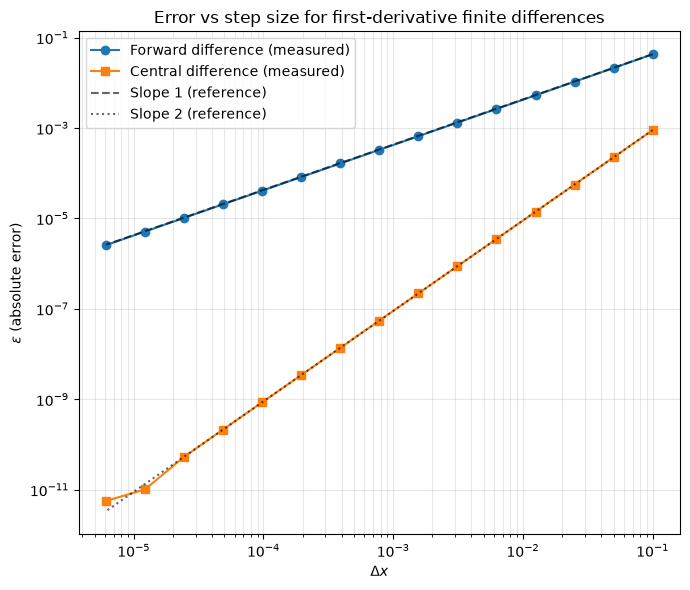

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.loglog(dx, eps_forward, "o-", label="Forward difference (measured)")
ax.loglog(dx, eps_central, "s-", label="Central difference (measured)")

# Reference slopes, anchored to the first data point of each series
ref_dx = np.array([dx[0], dx[-1]])
ax.loglog(ref_dx, eps_forward[0] * (ref_dx / dx[0]) ** 1, "k--", alpha=0.6, label="Slope 1 (reference)")
ax.loglog(ref_dx, eps_central[0] * (ref_dx / dx[0]) ** 2, "k:", alpha=0.6, label="Slope 2 (reference)")

ax.set_xlabel(r"$\Delta x$")
ax.set_ylabel(r"$\varepsilon$ (absolute error)")
ax.set_title("Error vs step size for first-derivative finite differences")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## Estimate the observed order of accuracy

We will estimate the order $p$ using the formula mentioned above:

$$p = \log_2\left(\frac{\varepsilon(\Delta x)}{\varepsilon(\Delta x / 2)}\right)$$

In [8]:
p_forward = np.log2(eps_forward[:-1] / eps_forward[1:])
p_central = np.log2(eps_central[:-1] / eps_central[1:])

print("dx           p_forward   p_central")
for i in range(len(p_forward)):
    print(f"{dx[i]:<12.3e} {p_forward[i]:<11.4f} {p_central[i]:<11.4f}")

dx           p_forward   p_central
1.000e-01    1.0143      1.9995     
5.000e-02    1.0074      1.9999     
2.500e-02    1.0038      2.0000     
1.250e-02    1.0019      2.0000     
6.250e-03    1.0010      2.0000     
3.125e-03    1.0005      2.0000     
1.563e-03    1.0002      2.0000     
7.813e-04    1.0001      2.0000     
3.906e-04    1.0001      2.0000     
1.953e-04    1.0000      1.9998     
9.766e-05    1.0000      1.9993     
4.883e-05    1.0000      2.0085     
2.441e-05    1.0000      2.3894     
1.221e-05    1.0000      0.8527     


## Conclusion

As $\Delta x$ decreases, `p_forward` converges to **1.0** and `p_central` converges to **2.0**, confirming that the
forward difference is first-order accurate and the central difference is second-order accurate. For the smallest
values of $\Delta x$, floating-point round-off error starts to dominate the truncation error, which is why the
estimated order degrades at the tail of the table/plot.